In [ ]:
!pip install -q ucimlrepo

In [ ]:
import sklearn
import joblib
import sys

print("Python:", sys.version)
print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Scikit-learn: 1.6.1
Joblib: 1.6.0


In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# Fetch UCI Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Get features and target
X = student_performance.data.features
y = student_performance.data.targets

# Combine them into one dataframe
df = pd.concat([X, y], axis=1)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (649, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Duplicate Rows: 0

Data Types:
school        object
sex           object


In [ ]:
# Basic statistics
print(df.describe())

              age        Medu        Fedu  traveltime   studytime    failures  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean    16.744222    2.514638    2.306626    1.568567    1.930663    0.221880   
std      1.218138    1.134552    1.099931    0.748660    0.829510    0.593235   
min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
25%     16.000000    2.000000    1.000000    1.000000    1.000000    0.000000   
50%     17.000000    2.000000    2.000000    1.000000    2.000000    0.000000   
75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   

           famrel    freetime       goout        Dalc        Walc      health  \
count  649.000000  649.000000  649.000000  649.000000  649.000000  649.000000   
mean     3.930663    3.180277    3.184900    1.502311    2.280431    3.536210   
std      0.955717    1.0510

In [ ]:
# Distribution of final grades
print(df["G3"].value_counts().sort_index())

G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


In [ ]:
# Check minimum and maximum final grade
print("Minimum G3:", df["G3"].min())
print("Maximum G3:", df["G3"].max())
print("Average G3:", df["G3"].mean())

Minimum G3: 0
Maximum G3: 19
Average G3: 11.906009244992296


In [ ]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print("\n", column)
    print(df[column].unique())


 school
['GP' 'MS']

 sex
['F' 'M']

 address
['U' 'R']

 famsize
['GT3' 'LE3']

 Pstatus
['A' 'T']

 Mjob
['at_home' 'health' 'other' 'services' 'teacher']

 Fjob
['teacher' 'other' 'services' 'health' 'at_home']

 reason
['course' 'other' 'home' 'reputation']

 guardian
['mother' 'father' 'other']

 schoolsup
['yes' 'no']

 famsup
['no' 'yes']

 paid
['no' 'yes']

 activities
['no' 'yes']

 nursery
['yes' 'no']

 higher
['yes' 'no']

 internet
['no' 'yes']

 romantic
['no' 'yes']


In [ ]:
# Create a copy of the dataset
data = df.copy()

# Remove G1 and G2 to reduce target leakage
data = data.drop(columns=["G1", "G2"])

print("New shape:", data.shape)
print(data.head())

New shape: (649, 31)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  internet romantic  famrel  freetime  goout Dalc Walc health absences  G3  
0       no       no       4         3      4    1    1      3        4  11  
1      yes       no       5         3      3    1    1      3        2  11  
2      yes       no       4         3      2    2    3      3        6  12  
3      yes      yes       3         2      2    1    1      5        0  14  
4       no       no       4         3      2    1    2      5        0  13  

[5 rows x 31 columns]


In [ ]:
X = data.drop(columns=["G3"])
y = data["G3"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (649, 30)
Target shape: (649,)


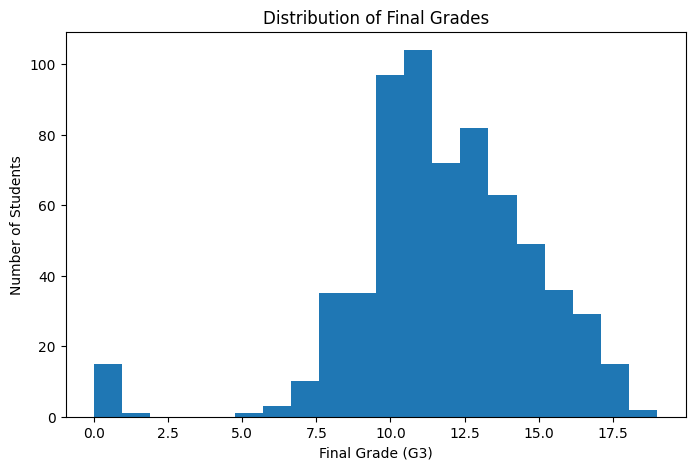

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(data["G3"], bins=20)
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.title("Distribution of Final Grades")
plt.show()

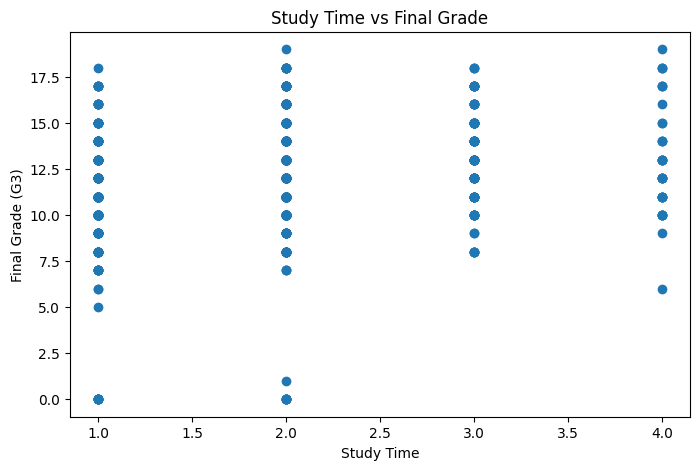

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(data["studytime"], data["G3"])
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")
plt.title("Study Time vs Final Grade")
plt.show()

/tmp/ipykernel_431/2917921733.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


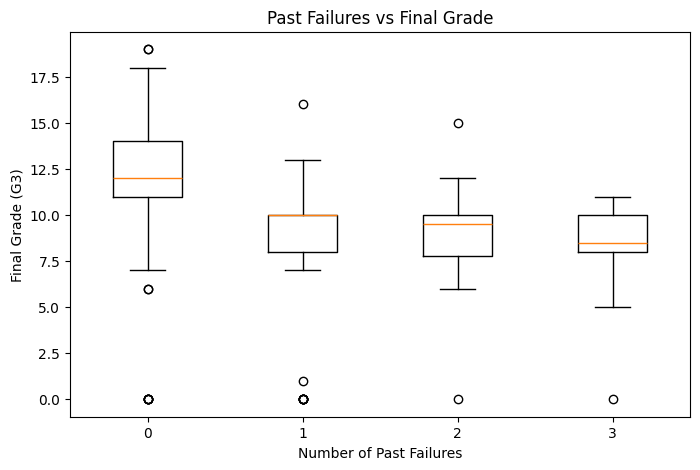

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [data[data["failures"] == i]["G3"] for i in sorted(data["failures"].unique())],
    labels=sorted(data["failures"].unique())
)

plt.xlabel("Number of Past Failures")
plt.ylabel("Final Grade (G3)")
plt.title("Past Failures vs Final Grade")
plt.show()

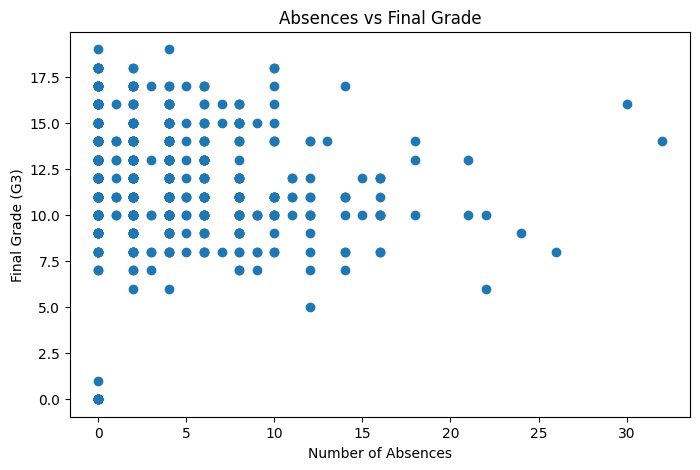

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(data["absences"], data["G3"])
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")
plt.title("Absences vs Final Grade")
plt.show()

In [ ]:
numeric_data = data.select_dtypes(include=["int64", "float64"])

correlation = numeric_data.corr()["G3"].sort_values(ascending=False)

print(correlation)

G3            1.000000
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


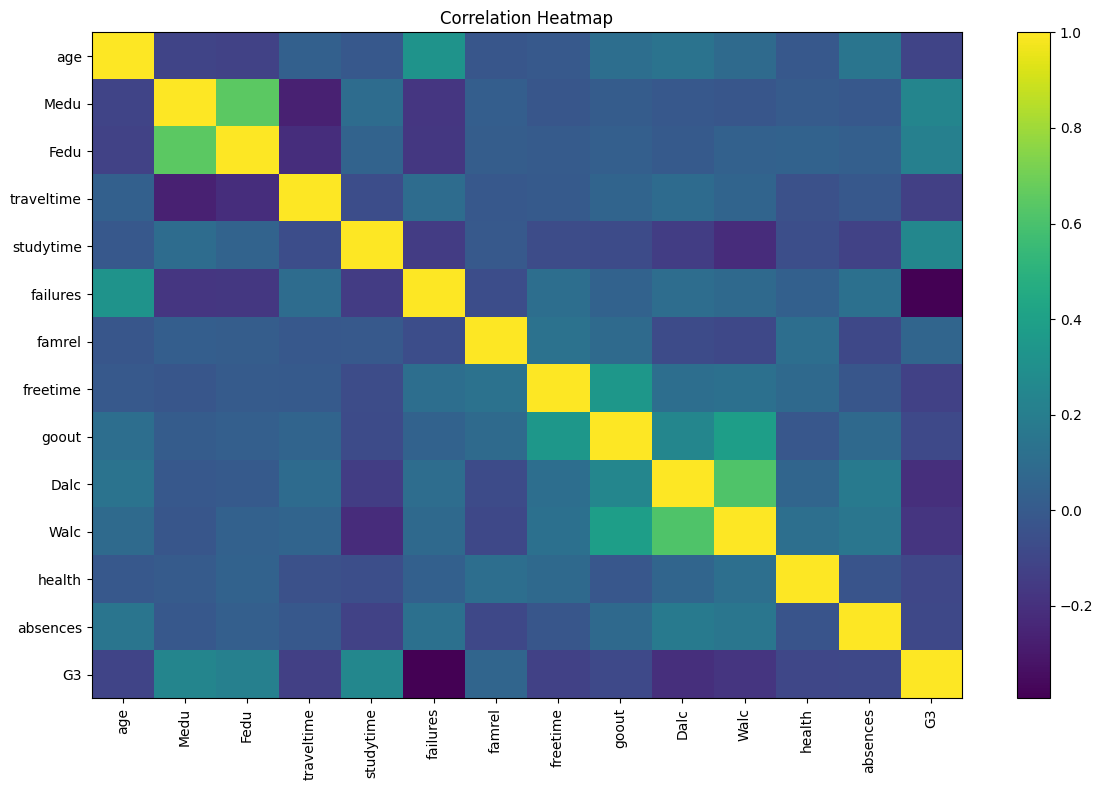

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.imshow(numeric_data.corr(), aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(numeric_data.columns)),
    numeric_data.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_data.columns)),
    numeric_data.columns
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
print(correlation)

G3            1.000000
studytime     0.249789
Medu          0.240151
Fedu          0.211800
famrel        0.063361
goout        -0.087641
absences     -0.091379
health       -0.098851
age          -0.106505
freetime     -0.122705
traveltime   -0.127173
Walc         -0.176619
Dalc         -0.204719
failures     -0.393316
Name: G3, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Separate features and target
X = data.drop(columns=["G3"])
y = data["G3"]

# Identify categorical and numerical columns
categorical_columns = X.select_dtypes(include=["object"]).columns
numerical_columns = X.select_dtypes(exclude=["object"]).columns

print("Categorical columns:")
print(list(categorical_columns))

print("\nNumerical columns:")
print(list(numerical_columns))

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 519
Testing samples: 130


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (519, 56)
Processed testing shape: (130, 56)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
linear_model = LinearRegression()

# Train model
linear_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_linear = linear_model.predict(X_test_processed)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 2.1563821870285276
MSE : 8.189784412019225
RMSE: 2.8617799377344206
R²  : 0.16016991964318272


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree model
decision_tree = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

# Train model
decision_tree.fit(X_train_processed, y_train)

# Make predictions
y_pred_tree = decision_tree.predict(X_test_processed)

# Evaluate model
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Results")
print("--------------------")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)

Decision Tree Results
--------------------
MAE : 2.4617809438498925
MSE : 10.972258736027264
RMSE: 3.3124399973474636
R²  : -0.1251618446085092


In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# Train model
random_forest.fit(X_train_processed, y_train)

# Make predictions
y_pred_forest = random_forest.predict(X_test_processed)

# Evaluate model
mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_forest)
print("MSE :", mse_forest)
print("RMSE:", rmse_forest)
print("R²  :", r2_forest)

Random Forest Results
---------------------
MAE : 2.0569938746135263
MSE : 7.9245571135872614
RMSE: 2.8150589893619036
R²  : 0.1873679326980855


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_tree,
        mae_forest
    ],
    "MSE": [
        mse,
        mse_tree,
        mse_forest
    ],
    "RMSE": [
        rmse,
        rmse_tree,
        rmse_forest
    ],
    "R2": [
        r2,
        r2_tree,
        r2_forest
    ]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,2.156382,8.189784,2.861780,0.160170
1,Decision Tree,2.461781,10.972259,3.312440,-0.125162
2,Random Forest,2.056994,7.924557,2.815059,0.187368


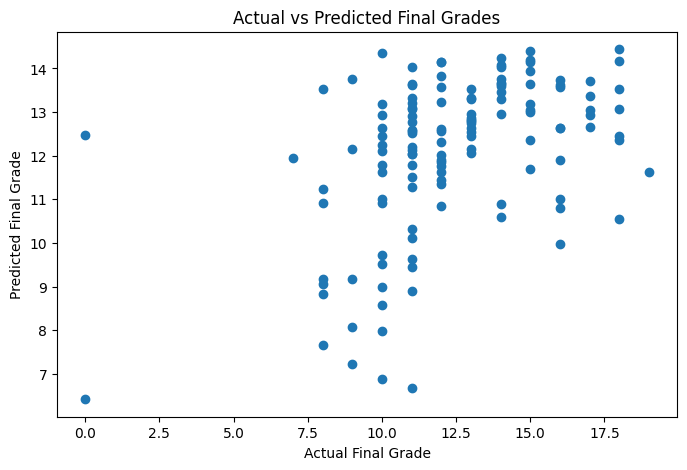

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_forest)

plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted Final Grades")

plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Actual Grade": y_test.values,
    "Predicted Grade": y_pred_forest
})

comparison["Error"] = (
    comparison["Actual Grade"] -
    comparison["Predicted Grade"]
)

comparison.head(15)

,Actual Grade,Predicted Grade,Error
0,19,11.620841,7.379159
1,12,12.559637,-0.559637
2,18,13.067440,4.932560
3,11,12.191319,-1.191319
4,11,12.028085,-1.028085
5,17,12.648814,4.351186
6,18,14.168012,3.831988
7,8,9.050504,-1.050504
8,10,12.251369,-2.251369
9,11,12.530136,-1.530136


In [ ]:
# Get feature names after one-hot encoding
encoded_columns = preprocessor.named_transformers_["categorical"].get_feature_names_out(
    categorical_columns
)

feature_names = list(encoded_columns) + list(numerical_columns)

# Get feature importance
importance = random_forest.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

         Feature  Importance
48      failures    0.250449
55      absences    0.067687
52          Dalc    0.047181
45          Fedu    0.045014
53          Walc    0.035582
51         goout    0.031630
1      school_MS    0.031104
50      freetime    0.030383
47     studytime    0.030070
44          Medu    0.029744
43           age    0.029175
54        health    0.027955
0      school_GP    0.025544
49        famrel    0.020048
22  reason_other    0.019088


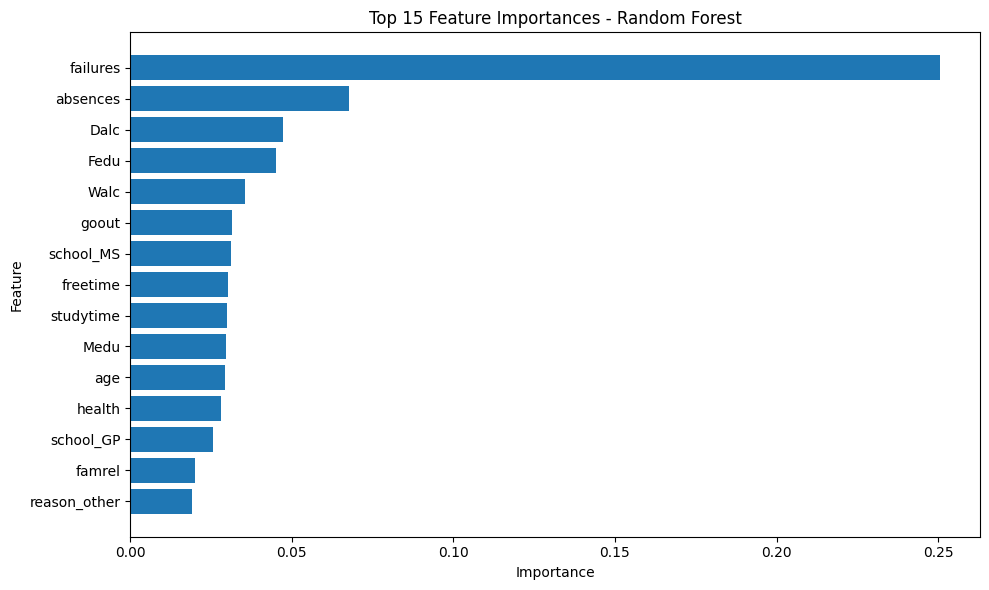

In [ ]:
top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Random Forest")

plt.tight_layout()
plt.show()

In [ ]:
print(feature_importance.head(15))

         Feature  Importance
48      failures    0.250449
55      absences    0.067687
52          Dalc    0.047181
45          Fedu    0.045014
53          Walc    0.035582
51         goout    0.031630
1      school_MS    0.031104
50      freetime    0.030383
47     studytime    0.030070
44          Medu    0.029744
43           age    0.029175
54        health    0.027955
0      school_GP    0.025544
49        famrel    0.020048
22  reason_other    0.019088


In [ ]:
# Create risk labels from final grade
data["Risk"] = data["G3"].apply(
    lambda x: "At Risk" if x < 10 else "Not At Risk"
)

print(data["Risk"].value_counts())

Risk
Not At Risk    549
At Risk        100
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Features and target
X_class = data.drop(columns=["G3", "Risk"])
y_class = data["Risk"]

# Identify columns
categorical_class = X_class.select_dtypes(include=["object"]).columns
numerical_class = X_class.select_dtypes(exclude=["object"]).columns

# Split data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Training samples:", X_train_class.shape[0])
print("Testing samples:", X_test_class.shape[0])

Training samples: 519
Testing samples: 130


In [ ]:
preprocessor_class = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_class
        )
    ],
    remainder="passthrough"
)

X_train_class_processed = preprocessor_class.fit_transform(X_train_class)
X_test_class_processed = preprocessor_class.transform(X_test_class)

print("Processed training shape:", X_train_class_processed.shape)
print("Processed testing shape:", X_test_class_processed.shape)

Processed training shape: (519, 56)
Processed testing shape: (130, 56)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create classifier
risk_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# Train
risk_model.fit(
    X_train_class_processed,
    y_train_class
)

# Predict
y_pred_risk = risk_model.predict(X_test_class_processed)

# Accuracy
accuracy = accuracy_score(
    y_test_class,
    y_pred_risk
)

print("Risk Classification Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test_class,
    y_pred_risk
))

Risk Classification Accuracy: 0.8076923076923077

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.22      0.10      0.14        20
 Not At Risk       0.85      0.94      0.89       110

    accuracy                           0.81       130
   macro avg       0.54      0.52      0.51       130
weighted avg       0.75      0.81      0.78       130



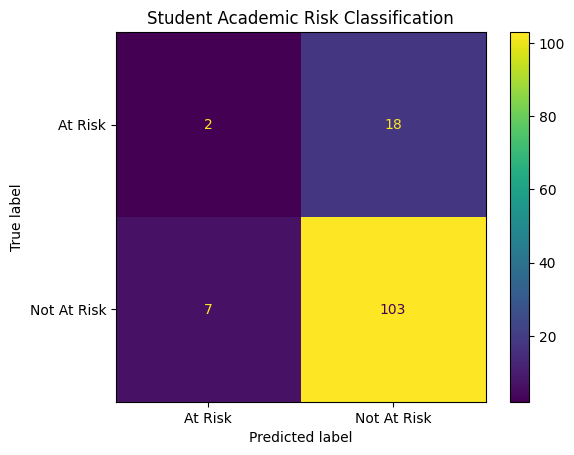

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    y_pred_risk
)

plt.title("Student Academic Risk Classification")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Balanced Random Forest
balanced_risk_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

# Train
balanced_risk_model.fit(
    X_train_class_processed,
    y_train_class
)

# Predict
y_pred_balanced = balanced_risk_model.predict(
    X_test_class_processed
)

# Accuracy
balanced_accuracy = accuracy_score(
    y_test_class,
    y_pred_balanced
)

print("Balanced Random Forest Accuracy:", balanced_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_balanced
    )
)

Balanced Random Forest Accuracy: 0.8

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.29      0.20      0.24        20
 Not At Risk       0.86      0.91      0.88       110

    accuracy                           0.80       130
   macro avg       0.57      0.55      0.56       130
weighted avg       0.77      0.80      0.79       130



In [ ]:
from sklearn.metrics import recall_score, f1_score

original_recall = recall_score(
    y_test_class,
    y_pred_risk,
    pos_label="At Risk"
)

balanced_recall = recall_score(
    y_test_class,
    y_pred_balanced,
    pos_label="At Risk"
)

original_f1 = f1_score(
    y_test_class,
    y_pred_risk,
    pos_label="At Risk"
)

balanced_f1 = f1_score(
    y_test_class,
    y_pred_balanced,
    pos_label="At Risk"
)

comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        accuracy,
        balanced_accuracy
    ],
    "At Risk Recall": [
        original_recall,
        balanced_recall
    ],
    "At Risk F1": [
        original_f1,
        balanced_f1
    ]
})

comparison

,Model,Accuracy,At Risk Recall,At Risk F1
0,Random Forest,0.807692,0.1,0.137931
1,Balanced Random Forest,0.800000,0.2,0.235294


In [ ]:
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_class_processed,
    y_train_class
)

print("Before SMOTE:")
print(y_train_class.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Train Random Forest
smote_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

# Prediction
y_pred_smote = smote_model.predict(
    X_test_class_processed
)

# Evaluation
smote_accuracy = accuracy_score(
    y_test_class,
    y_pred_smote
)

print("\nSMOTE Random Forest Accuracy:", smote_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_smote
    )
)

Before SMOTE:
Risk
Not At Risk    439
At Risk         80
Name: count, dtype: int64

After SMOTE:
Risk
Not At Risk    439
At Risk        439
Name: count, dtype: int64

SMOTE Random Forest Accuracy: 0.7923076923076923

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.29      0.25      0.27        20
 Not At Risk       0.87      0.89      0.88       110

    accuracy                           0.79       130
   macro avg       0.58      0.57      0.57       130
weighted avg       0.78      0.79      0.79       130



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_class_processed,
    y_train_class
)

y_pred_logistic = logistic_model.predict(
    X_test_class_processed
)

logistic_accuracy = accuracy_score(
    y_test_class,
    y_pred_logistic
)

print("Balanced Logistic Regression Accuracy:", logistic_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_logistic
    )
)


Balanced Logistic Regression Accuracy: 0.6538461538461539

Classification Report:
              precision    recall  f1-score   support

     At Risk       0.21      0.45      0.29        20
 Not At Risk       0.87      0.69      0.77       110

    accuracy                           0.65       130
   macro avg       0.54      0.57      0.53       130
weighted avg       0.77      0.65      0.70       130



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Models
rf_model = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        random_state=42
    ))
])

balanced_rf_model = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model_cv = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

# Scoring
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        pos_label="At Risk",
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        pos_label="At Risk",
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        pos_label="At Risk",
        zero_division=0
    )
}

models = {
    "Random Forest": rf_model,
    "Balanced Random Forest": balanced_rf_model,
    "Balanced Logistic Regression": logistic_model_cv
}

results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_class,
        y_class,
        cv=cv,
        scoring=scoring
    )

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "At Risk Precision": scores["test_precision"].mean(),
        "At Risk Recall": scores["test_recall"].mean(),
        "At Risk F1": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(results)

cv_results

,Model,Accuracy,At Risk Precision,At Risk Recall,At Risk F1
0,Random Forest,0.852069,0.505000,0.13,0.204857
1,Balanced Random Forest,0.850555,0.587692,0.22,0.304848
2,Balanced Logistic Regression,0.765760,0.356371,0.67,0.462947


In [ ]:
# Train the final risk prediction model

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

final_risk_model = Pipeline([
    ("preprocessor", preprocessor_class),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

final_risk_model.fit(X_class, y_class)

print("Final risk prediction model trained successfully!")

Final risk prediction model trained successfully!


In [ ]:
def predict_student_risk(student_data):

    student_df = pd.DataFrame([student_data])

    prediction = final_risk_model.predict(student_df)[0]

    probability = final_risk_model.predict_proba(student_df)[0]

    classes = final_risk_model.named_steps["model"].classes_

    risk_probability = probability[
        list(classes).index("At Risk")
    ]

    print("Predicted Risk:", prediction)
    print("At Risk Probability:", round(risk_probability * 100, 2), "%")

    if prediction == "At Risk":
        print("Recommendation: Student may require additional academic support.")
    else:
        print("Recommendation: Student is currently not classified as At Risk.")

In [ ]:
student = {
    "school": "GP",
    "sex": "M",
    "age": 17,
    "address": "U",
    "famsize": "GT3",
    "Pstatus": "A",
    "Medu": 2,
    "Fedu": 2,
    "Mjob": "services",
    "Fjob": "other",
    "reason": "course",
    "guardian": "mother",
    "traveltime": 2,
    "studytime": 1,
    "failures": 2,
    "schoolsup": "no",
    "famsup": "no",
    "paid": "no",
    "activities": "no",
    "nursery": "yes",
    "higher": "yes",
    "internet": "yes",
    "romantic": "no",
    "famrel": 3,
    "freetime": 4,
    "goout": 4,
    "Dalc": 2,
    "Walc": 3,
    "health": 4,
    "absences": 15
}

predict_student_risk(student)

Predicted Risk: At Risk
At Risk Probability: 92.23 %
Recommendation: Student may require additional academic support.


In [ ]:
import joblib

# Save the trained model
joblib.dump(
    final_risk_model,
    "student_risk_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.path.exists("student_risk_model.pkl"))
print("File size:", os.path.getsize("student_risk_model.pkl"), "bytes")

True
File size: 8113 bytes


In [ ]:
from google.colab import files

files.download("student_risk_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>